<a href="https://colab.research.google.com/github/zhangwiki86-soton/L7---Data-Analysis-and-Visualisation/blob/main/DRAFT%20Test%20Glob.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crime Data Analysis of WMP

#Clone files from Github

In [1]:
!pip install panel jupyter_bokeh
!pip install hvplot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.6/148.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.5 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 10.8 MB/s eta 0:00:00


In [2]:
! git clone https://github.com/zhangwiki86-soton/L7---Data-Analysis-and-Visualisation.git
#/content/L7---Data-Analysis-and-Visualisation

Cloning into 'L7---Data-Analysis-and-Visualisation'...
remote: Enumerating objects: 185, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 185 (delta 28), reused 20 (delta 20), pack-reused 153 (from 1)
Receiving objects: 100% (185/185), 44.67 MiB | 29.94 MiB/s, done.
Resolving deltas: 100% (116/116), done.
Updating files: 100% (55/55), done.


#1. Importing Libriaries

In [3]:
import pandas as pd
import glob as glob
import panel as pn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pn.extension(comms='colab')
pn.extension('tabulator')
import hvplot.pandas

#2. Import Data

In [4]:
RawData=glob.glob("/content/L7---Data-Analysis-and-Visualisation/Raw Data/*.csv")
RawData

['/content/L7---Data-Analysis-and-Visualisation/Raw Data/2023-12-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-12-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-02-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-08-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-03-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-10-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-04-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-09-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2024-09-west-midlands-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-05-staffordshire-street.csv',
 '/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025-07-staffordshire-s

In [5]:
list_df=[]
for csvfile in RawData:
  df=pd.read_csv(csvfile)
  list_df.append(df)

In [6]:
  list_df

[                                                Crime ID    Month  \
 0      fdbff4da55066884700d48f6ca48e03fbe8a75b6a143cc...  2023-12   
 1      02affdeba7ab5d450fe62e72a2009d0cd796d5aa66f5a2...  2023-12   
 2      9e26f25dc8749749da9e14400236bec7f30872cfe75f9a...  2023-12   
 3      4026edb36cf730ba9ac2b5d7e385d3d20c26fb5c07927c...  2023-12   
 4      452f4613d8c6ca1ba1bdd38b592641bb8d1aafcbf19ea9...  2023-12   
 ...                                                  ...      ...   
 28053  629ce5e95a89bf032c096076cef93fcffb906e3d368891...  2023-12   
 28054  ec6985a3b3eab5230828972c4ac594890dd9b7facc6509...  2023-12   
 28055  dd3213d01939c41ff5f3f2353ea6c20937c820bc9007b1...  2023-12   
 28056  bb58815c89bf8e7382f852daf631f2a92a5c961432eb8e...  2023-12   
 28057  442ad91c7d0baa110aae672059cdaeffc7e3f46e2ae6df...  2023-12   
 
                 Reported by          Falls within  Longitude   Latitude  \
 0      West Midlands Police  West Midlands Police  -1.849790  52.590937   
 1    

In [7]:
len(list_df)

48

In [8]:
CrimeData = pd.concat(list_df,axis=0, ignore_index=True) # axis=0 meaning row concatenation and 1 is for column
CrimeData

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,fdbff4da55066884700d48f6ca48e03fbe8a75b6a143cc...,2023-12,West Midlands Police,West Midlands Police,-1.849790,52.590937,On or near Walsall Road,E01009417,Birmingham 001A,Public order,Unable to prosecute suspect,NaN
1,02affdeba7ab5d450fe62e72a2009d0cd796d5aa66f5a2...,2023-12,West Midlands Police,West Midlands Police,-1.849790,52.590937,On or near Walsall Road,E01009417,Birmingham 001A,Theft from the person,Investigation complete; no suspect identified,NaN
2,9e26f25dc8749749da9e14400236bec7f30872cfe75f9a...,2023-12,West Midlands Police,West Midlands Police,-1.847123,52.593864,On or near Bramble Way,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified,NaN
3,4026edb36cf730ba9ac2b5d7e385d3d20c26fb5c07927c...,2023-12,West Midlands Police,West Midlands Police,-1.849790,52.590937,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Unable to prosecute suspect,NaN
4,452f4613d8c6ca1ba1bdd38b592641bb8d1aafcbf19ea9...,2023-12,West Midlands Police,West Midlands Police,-1.849790,52.590937,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Investigation complete; no suspect identified,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
869242,070e2c1dd2e166614daff588e18d6b40e83659f885caeb...,2025-05,West Midlands Police,West Midlands Police,-2.113610,52.570768,On or near Whittaker Street,E01034314,Wolverhampton 035I,Violence and sexual offences,Unable to prosecute suspect,NaN
869243,d6cfb93f41787fd981399e9adbdf47a1e4fe44490d3000...,2025-05,West Midlands Police,West Midlands Police,-2.111371,52.572155,On or near Dixon Street,E01034314,Wolverhampton 035I,Violence and sexual offences,Investigation complete; no suspect identified,NaN
869244,7305ccfd6adc93c34c47038559ac338b1905becd3d89d3...,2025-05,West Midlands Police,West Midlands Police,-2.117890,52.570935,On or near Rowan Tree Drive,E01034315,Wolverhampton 035J,Criminal damage and arson,Unable to prosecute suspect,NaN
869245,bf72461fecbd6f94b4441391610ed382950f6f074f9988...,2025-05,West Midlands Police,West Midlands Police,-2.115445,52.572564,On or near Howell Road,E01034315,Wolverhampton 035J,Drugs,Local resolution,NaN


#Structure and Shape

In [9]:
CrimeData.shape # Dimentions of the DataFrame (number of rows and columns)

(869247, 12)

In [10]:
CrimeData.index #
#CrimeData.index.to_list()

RangeIndex(start=0, stop=869247, step=1)

In [11]:
print("colomns:\n", CrimeData.columns) # Column names of the DataFrame
print("colomns:\n", CrimeData.columns.to_list()) # In list

colomns:
 Index(['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude',
       'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type',
       'Last outcome category', 'Context'],
      dtype='object')
colomns:
 ['Crime ID', 'Month', 'Reported by', 'Falls within', 'Longitude', 'Latitude', 'Location', 'LSOA code', 'LSOA name', 'Crime type', 'Last outcome category', 'Context']


In [12]:
CrimeData.info()
# number of rows/records
# any null values in each colum, how complete the columns are populated in the data set
# what are the types of attributes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869247 entries, 0 to 869246
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Crime ID               789910 non-null  object 
 1   Month                  869247 non-null  object 
 2   Reported by            869247 non-null  object 
 3   Falls within           869247 non-null  object 
 4   Longitude              868316 non-null  float64
 5   Latitude               868316 non-null  float64
 6   Location               869247 non-null  object 
 7   LSOA code              868316 non-null  object 
 8   LSOA name              868316 non-null  object 
 9   Crime type             869247 non-null  object 
 10  Last outcome category  789910 non-null  object 
 11  Context                0 non-null       float64
dtypes: float64(3), object(9)
memory usage: 79.6+ MB


#Content

In [13]:
CrimeData.head()
CrimeData.tail()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
869242,070e2c1dd2e166614daff588e18d6b40e83659f885caeb...,2025-05,West Midlands Police,West Midlands Police,-2.113610,52.570768,On or near Whittaker Street,E01034314,Wolverhampton 035I,Violence and sexual offences,Unable to prosecute suspect,NaN
869243,d6cfb93f41787fd981399e9adbdf47a1e4fe44490d3000...,2025-05,West Midlands Police,West Midlands Police,-2.111371,52.572155,On or near Dixon Street,E01034314,Wolverhampton 035I,Violence and sexual offences,Investigation complete; no suspect identified,NaN
869244,7305ccfd6adc93c34c47038559ac338b1905becd3d89d3...,2025-05,West Midlands Police,West Midlands Police,-2.117890,52.570935,On or near Rowan Tree Drive,E01034315,Wolverhampton 035J,Criminal damage and arson,Unable to prosecute suspect,NaN
869245,bf72461fecbd6f94b4441391610ed382950f6f074f9988...,2025-05,West Midlands Police,West Midlands Police,-2.115445,52.572564,On or near Howell Road,E01034315,Wolverhampton 035J,Drugs,Local resolution,NaN
869246,bd1b1af007442a976d80900ca8b347ac6cf2da8fdf7093...,2025-05,West Midlands Police,West Midlands Police,-2.117079,52.571358,On or near Willcock Road,E01034315,Wolverhampton 035J,Violence and sexual offences,Unable to prosecute suspect,NaN


#Detecting missing values

In [14]:
CrimeData.isna()
CrimeData.isnull()
CrimeData.isna().sum()
CrimeData.isnull().sum()

,0
Crime ID,79337
Month,0
Reported by,0
Falls within,0
Longitude,931
Latitude,931
Location,0
LSOA code,931
LSOA name,931
Crime type,0


#Selecting part of the DataFrame or Drop parts not needed

In [15]:
CleanData=CrimeData.loc[:, ['Month', 'Reported by','Location','LSOA code','LSOA name','Crime type','Last outcome category']] #select Columns needed
CleanData

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,2023-12,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Public order,Unable to prosecute suspect
1,2023-12,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Theft from the person,Investigation complete; no suspect identified
2,2023-12,West Midlands Police,On or near Bramble Way,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified
3,2023-12,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Unable to prosecute suspect
4,2023-12,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Investigation complete; no suspect identified
...,...,...,...,...,...,...,...
869242,2025-05,West Midlands Police,On or near Whittaker Street,E01034314,Wolverhampton 035I,Violence and sexual offences,Unable to prosecute suspect
869243,2025-05,West Midlands Police,On or near Dixon Street,E01034314,Wolverhampton 035I,Violence and sexual offences,Investigation complete; no suspect identified
869244,2025-05,West Midlands Police,On or near Rowan Tree Drive,E01034315,Wolverhampton 035J,Criminal damage and arson,Unable to prosecute suspect
869245,2025-05,West Midlands Police,On or near Howell Road,E01034315,Wolverhampton 035J,Drugs,Local resolution


In [16]:
#Double Check if both datasets brought in
CleanData['Reported by'].value_counts()

,count
Reported by,
West Midlands Police,668108
Staffordshire Police,201139


# Handling Missing Data

In [ ]:
CleanData.fillna('Data not recorded', inplace=True) # Fill the blank values with 'data not recorded' for outcome column
CleanData.info() # check if fillna worked

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 869247 entries, 0 to 869246
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Month                  869247 non-null  object
 1   Reported by            869247 non-null  object
 2   Location               869247 non-null  object
 3   LSOA code              869247 non-null  object
 4   LSOA name              869247 non-null  object
 5   Crime type             869247 non-null  object
 6   Last outcome category  869247 non-null  object
dtypes: object(7)
memory usage: 46.4+ MB


In [17]:
CleanData

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category
0,2023-12,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Public order,Unable to prosecute suspect
1,2023-12,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Theft from the person,Investigation complete; no suspect identified
2,2023-12,West Midlands Police,On or near Bramble Way,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified
3,2023-12,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Unable to prosecute suspect
4,2023-12,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Investigation complete; no suspect identified
...,...,...,...,...,...,...,...
869242,2025-05,West Midlands Police,On or near Whittaker Street,E01034314,Wolverhampton 035I,Violence and sexual offences,Unable to prosecute suspect
869243,2025-05,West Midlands Police,On or near Dixon Street,E01034314,Wolverhampton 035I,Violence and sexual offences,Investigation complete; no suspect identified
869244,2025-05,West Midlands Police,On or near Rowan Tree Drive,E01034315,Wolverhampton 035J,Criminal damage and arson,Unable to prosecute suspect
869245,2025-05,West Midlands Police,On or near Howell Road,E01034315,Wolverhampton 035J,Drugs,Local resolution


#Handling Data Quality Issue
Review Crimes and Outcomes, check any duplication/Similar inputs to tidy up

In [18]:
CleanData['Crime type'].value_counts()
CleanData['Last outcome category'].value_counts()

,count
Last outcome category,
Unable to prosecute suspect,396638
Investigation complete; no suspect identified,250736
Court result unavailable,38529
Local resolution,26314
Awaiting court outcome,22573
Status update unavailable,18453
Under investigation,17037
Action to be taken by another organisation,11528
Offender given a caution,5507


In [19]:
# Handling typo or duplications
CleanData.replace({"Formal action is not in the public interest":"Further action is not in the public interest"}, inplace=True)
CleanData.replace({"Further investigation is not in the public interest":"Further action is not in the public interest"}, inplace=True)


In [20]:
CleanData['Last outcome category'].value_counts()

,count
Last outcome category,
Unable to prosecute suspect,396638
Investigation complete; no suspect identified,250736
Court result unavailable,38529
Local resolution,26314
Awaiting court outcome,22573
Status update unavailable,18453
Under investigation,17037
Action to be taken by another organisation,11528
Offender given a caution,5507


1.   Bring in two workforce data
2.   Import LSOA data in one sheet
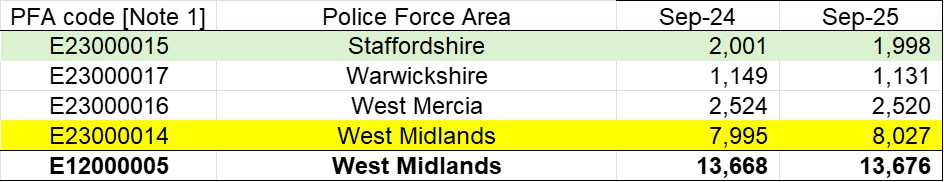


In [33]:
FTE={
    'Reported by': ['West Midlands Police', 'Staffordshire Police'],
        'Police FTE': ['8027',	'1998']}
WorkForceFTE = pd.DataFrame(FTE)
WorkForceFTE

,Reported by,Police FTE
0,West Midlands Police,8027
1,Staffordshire Police,1998


#Merge supplimentary datasets
Append Police Work Force Data

Append LSOA Data


In [22]:
LSOAdata=pd.read_excel("/content/L7---Data-Analysis-and-Visualisation/Raw Data/2025_All_Ranks_Scores_Deciles_Population_Denominators.xlsx")
LSOAdata

,LSOA code (2021),LSOA name (2021),Local Authority District code (2024),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Income Score (rate),Income Rank (where 1 is most deprived),Income Decile (where 1 is most deprived 10% of LSOAs),Employment Score (rate),Employment Rank (where 1 is most deprived),Employment Decile (where 1 is most deprived 10% of LSOAs),"Education, Skills and Training Score","Education, Skills and Training Rank (where 1 is most deprived)","Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)",Population LSOA
0,E01000001,City of London 001A,E09000001,City of London,8.742,26525,8,0.013,33730,10,0.014,33708,10,0.004,33755,10,2172
1,E01000002,City of London 001B,E09000001,City of London,4.722,31203,10,0.018,33669,10,0.010,33734,10,0.169,33672,10,2044
2,E01000003,City of London 001C,E09000001,City of London,9.250,25913,8,0.107,25167,8,0.064,26985,8,3.269,30273,9,2444
3,E01000005,City of London 001E,E09000001,City of London,19.884,14807,5,0.211,14836,5,0.104,17911,6,17.852,15886,5,2391
4,E01000006,Barking and Dagenham 016A,E09000002,Barking and Dagenham,25.307,10917,4,0.343,7519,3,0.120,15286,5,25.442,11134,4,1930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33750,E01035758,Vale of White Horse 014H,E07000180,Vale of White Horse,7.945,27536,9,0.101,25934,8,0.074,24575,8,10.893,21842,7,1216
33751,E01035759,Vale of White Horse 015G,E07000180,Vale of White Horse,7.622,27902,9,0.097,26440,8,0.081,22891,7,7.528,25326,8,1592
33752,E01035760,Vale of White Horse 015H,E07000180,Vale of White Horse,7.946,27532,9,0.170,18127,6,0.067,26383,8,10.064,22625,7,1827
33753,E01035761,Vale of White Horse 015I,E07000180,Vale of White Horse,6.682,28981,9,0.136,21596,7,0.054,29547,9,8.482,24267,8,1955


In [23]:
LSOAdataclean=LSOAdata.loc[:, ['LSOA code (2021)','Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)','Income Rank (where 1 is most deprived)','Employment Rank (where 1 is most deprived)','Education, Skills and Training Rank (where 1 is most deprived)','Population LSOA']] #select Columns needed
LSOAdataclean

,LSOA code (2021),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Income Rank (where 1 is most deprived),Employment Rank (where 1 is most deprived),"Education, Skills and Training Rank (where 1 is most deprived)",Population LSOA
0,E01000001,26525,33730,33708,33755,2172
1,E01000002,31203,33669,33734,33672,2044
2,E01000003,25913,25167,26985,30273,2444
3,E01000005,14807,14836,17911,15886,2391
4,E01000006,10917,7519,15286,11134,1930
...,...,...,...,...,...,...
33750,E01035758,27536,25934,24575,21842,1216
33751,E01035759,27902,26440,22891,25326,1592
33752,E01035760,27532,18127,26383,22625,1827
33753,E01035761,28981,21596,29547,24267,1955


#Rename Column for easy join

In [26]:
LSOAdataclean.rename(columns={'LSOA code (2021)':'LSOA code'}, inplace=True)
LSOAdataclean

,LSOA code,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Income Rank (where 1 is most deprived),Employment Rank (where 1 is most deprived),"Education, Skills and Training Rank (where 1 is most deprived)",Population LSOA
0,E01000001,26525,33730,33708,33755,2172
1,E01000002,31203,33669,33734,33672,2044
2,E01000003,25913,25167,26985,30273,2444
3,E01000005,14807,14836,17911,15886,2391
4,E01000006,10917,7519,15286,11134,1930
...,...,...,...,...,...,...
33750,E01035758,27536,25934,24575,21842,1216
33751,E01035759,27902,26440,22891,25326,1592
33752,E01035760,27532,18127,26383,22625,1827
33753,E01035761,28981,21596,29547,24267,1955


In [38]:
#Merge LSOA data
DataMerge1=pd.merge(CleanData,LSOAdataclean,on='LSOA code',how='left')
#Merge workforce data
DataMerge=pd.merge(DataMerge1,WorkForceFTE,on='Reported by',how='left')
DataMerge

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Income Rank (where 1 is most deprived),Employment Rank (where 1 is most deprived),"Education, Skills and Training Rank (where 1 is most deprived)",Population LSOA,Police FTE
0,2023-12,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Public order,Unable to prosecute suspect,27056.0,23759.0,24715.0,30287.0,1554.0,8027
1,2023-12,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Theft from the person,Investigation complete; no suspect identified,27056.0,23759.0,24715.0,30287.0,1554.0,8027
2,2023-12,West Midlands Police,On or near Bramble Way,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified,27056.0,23759.0,24715.0,30287.0,1554.0,8027
3,2023-12,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Unable to prosecute suspect,27056.0,23759.0,24715.0,30287.0,1554.0,8027
4,2023-12,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Investigation complete; no suspect identified,27056.0,23759.0,24715.0,30287.0,1554.0,8027
...,...,...,...,...,...,...,...,...,...,...,...,...,...
869242,2025-05,West Midlands Police,On or near Whittaker Street,E01034314,Wolverhampton 035I,Violence and sexual offences,Unable to prosecute suspect,5010.0,2977.0,4543.0,7984.0,2172.0,8027
869243,2025-05,West Midlands Police,On or near Dixon Street,E01034314,Wolverhampton 035I,Violence and sexual offences,Investigation complete; no suspect identified,5010.0,2977.0,4543.0,7984.0,2172.0,8027
869244,2025-05,West Midlands Police,On or near Rowan Tree Drive,E01034315,Wolverhampton 035J,Criminal damage and arson,Unable to prosecute suspect,8456.0,4892.0,10724.0,6200.0,1372.0,8027
869245,2025-05,West Midlands Police,On or near Howell Road,E01034315,Wolverhampton 035J,Drugs,Local resolution,8456.0,4892.0,10724.0,6200.0,1372.0,8027


In [39]:
#change data type for Column "Month"
DataMerge['Month'] = pd.to_datetime(DataMerge['Month'])
start_date = pd.to_datetime('2023-12')
end_date = pd.to_datetime('2024-11')

DataMerge['Month Group'] = DataMerge['Month'].apply(lambda x: 'first 12 months' if (x >= start_date and x <= end_date) else 'second 12 months')
DataMerge

,Month,Reported by,Location,LSOA code,LSOA name,Crime type,Last outcome category,Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Income Rank (where 1 is most deprived),Employment Rank (where 1 is most deprived),"Education, Skills and Training Rank (where 1 is most deprived)",Population LSOA,Police FTE,Month Group
0,2023-12-01,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Public order,Unable to prosecute suspect,27056.0,23759.0,24715.0,30287.0,1554.0,8027,first 12 months
1,2023-12-01,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Theft from the person,Investigation complete; no suspect identified,27056.0,23759.0,24715.0,30287.0,1554.0,8027,first 12 months
2,2023-12-01,West Midlands Police,On or near Bramble Way,E01009417,Birmingham 001A,Vehicle crime,Investigation complete; no suspect identified,27056.0,23759.0,24715.0,30287.0,1554.0,8027,first 12 months
3,2023-12-01,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Unable to prosecute suspect,27056.0,23759.0,24715.0,30287.0,1554.0,8027,first 12 months
4,2023-12-01,West Midlands Police,On or near Walsall Road,E01009417,Birmingham 001A,Violence and sexual offences,Investigation complete; no suspect identified,27056.0,23759.0,24715.0,30287.0,1554.0,8027,first 12 months
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869242,2025-05-01,West Midlands Police,On or near Whittaker Street,E01034314,Wolverhampton 035I,Violence and sexual offences,Unable to prosecute suspect,5010.0,2977.0,4543.0,7984.0,2172.0,8027,second 12 months
869243,2025-05-01,West Midlands Police,On or near Dixon Street,E01034314,Wolverhampton 035I,Violence and sexual offences,Investigation complete; no suspect identified,5010.0,2977.0,4543.0,7984.0,2172.0,8027,second 12 months
869244,2025-05-01,West Midlands Police,On or near Rowan Tree Drive,E01034315,Wolverhampton 035J,Criminal damage and arson,Unable to prosecute suspect,8456.0,4892.0,10724.0,6200.0,1372.0,8027,second 12 months
869245,2025-05-01,West Midlands Police,On or near Howell Road,E01034315,Wolverhampton 035J,Drugs,Local resolution,8456.0,4892.0,10724.0,6200.0,1372.0,8027,second 12 months


#Creat NEW Column 'Weighted Crime/1000 WTF police'
#Creat NEW Column 'Weighted Crime/1000 population'


In [ ]:
crime_counts = DataMerge.groupby(['Month', 'Reported by', 'LSOA code', 'Population LSOA', 'Police FTE', 'A']).size().reset_index(name='CrimeCount')

crime_counts['Weighted Crime/1000 WTF police'] = (crime_counts['CrimeCount'] / crime_counts['Police FTE'].astype(float)) * 1000
crime_counts['Weighted Crime/1000 population'] = (crime_counts['CrimeCount'] / crime_counts['Population LSOA'].astype(float)) * 1000
crime_counts

#Analysis Visualisation

In [ ]:
CleanData['Crime type'].value_counts()

,count
Crime type,
Violence and sexual offences,166045
Vehicle crime,38367
Shoplifting,37859
Anti-social behaviour,33782
Criminal damage and arson,31230
Other theft,27051
Public order,23771
Burglary,21308
Drugs,9982


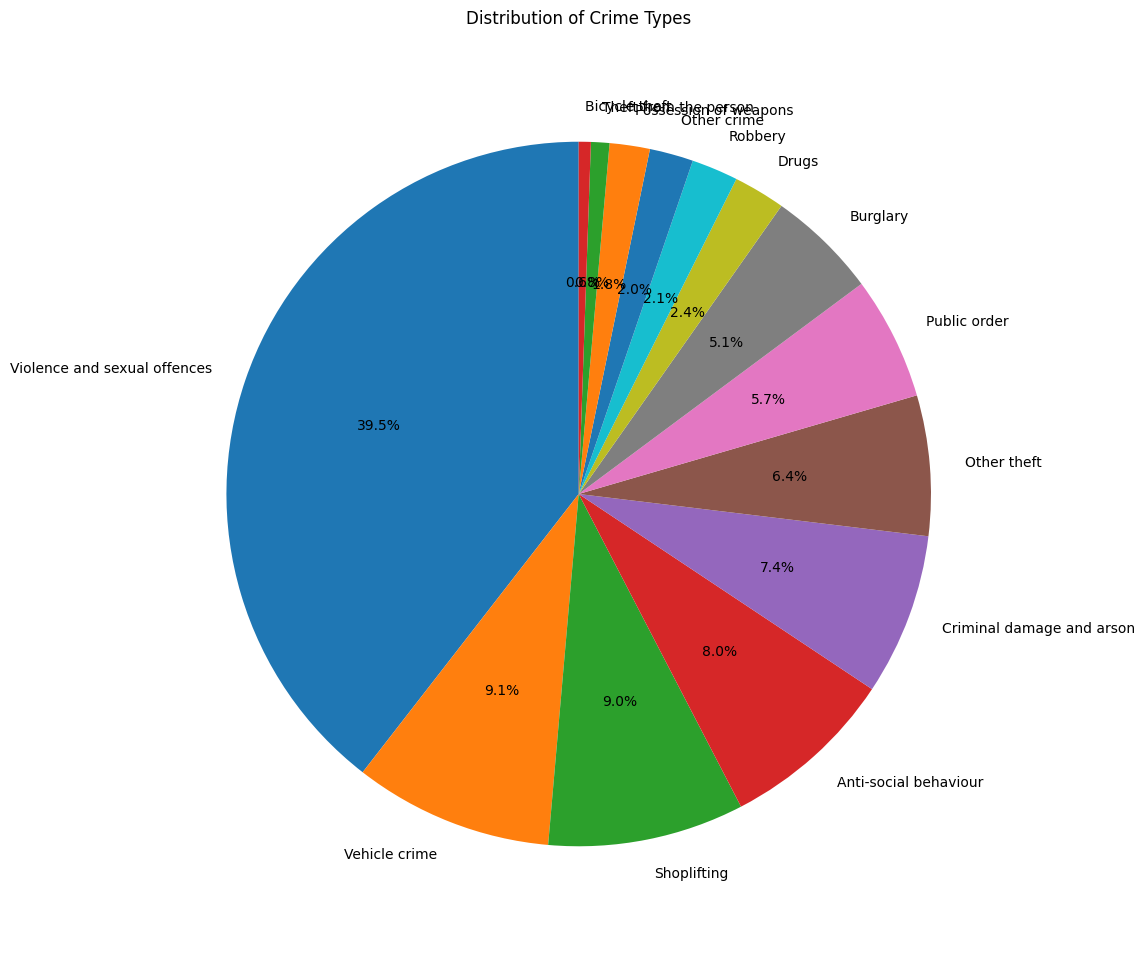

In [ ]:
#Simple Pie chart
crime_type_counts = CleanData['Crime type'].value_counts()
categories = crime_type_counts.index
values = crime_type_counts.values

plt.figure(figsize=(10, 12)) # Adjust figure size for better readability
plt.pie(values, labels=categories, autopct='%1.1f%%', radius=1, startangle=90)
plt.title('Distribution of Crime Types')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

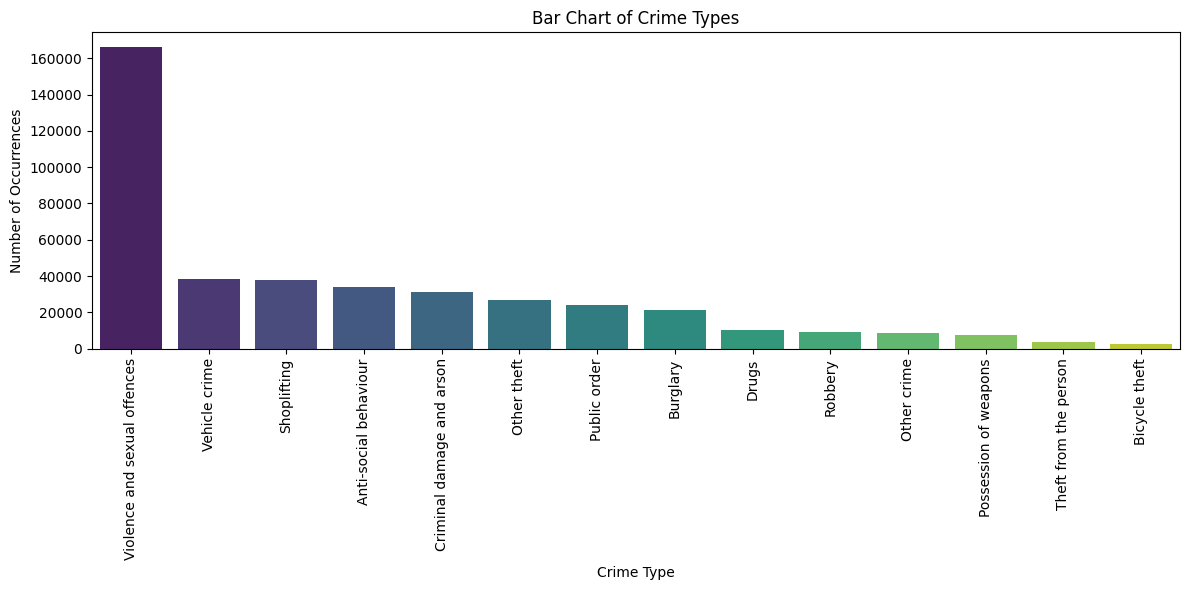

In [ ]:
#Simple Bar Chart
crime_type_counts = CleanData['Crime type'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=crime_type_counts.index, y=crime_type_counts.values, hue=crime_type_counts.index, palette='viridis', legend=False)
plt.title('Bar Chart of Crime Types')
plt.xlabel('Crime Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability if many categories
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

/tmp/ipython-input-3109740435.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


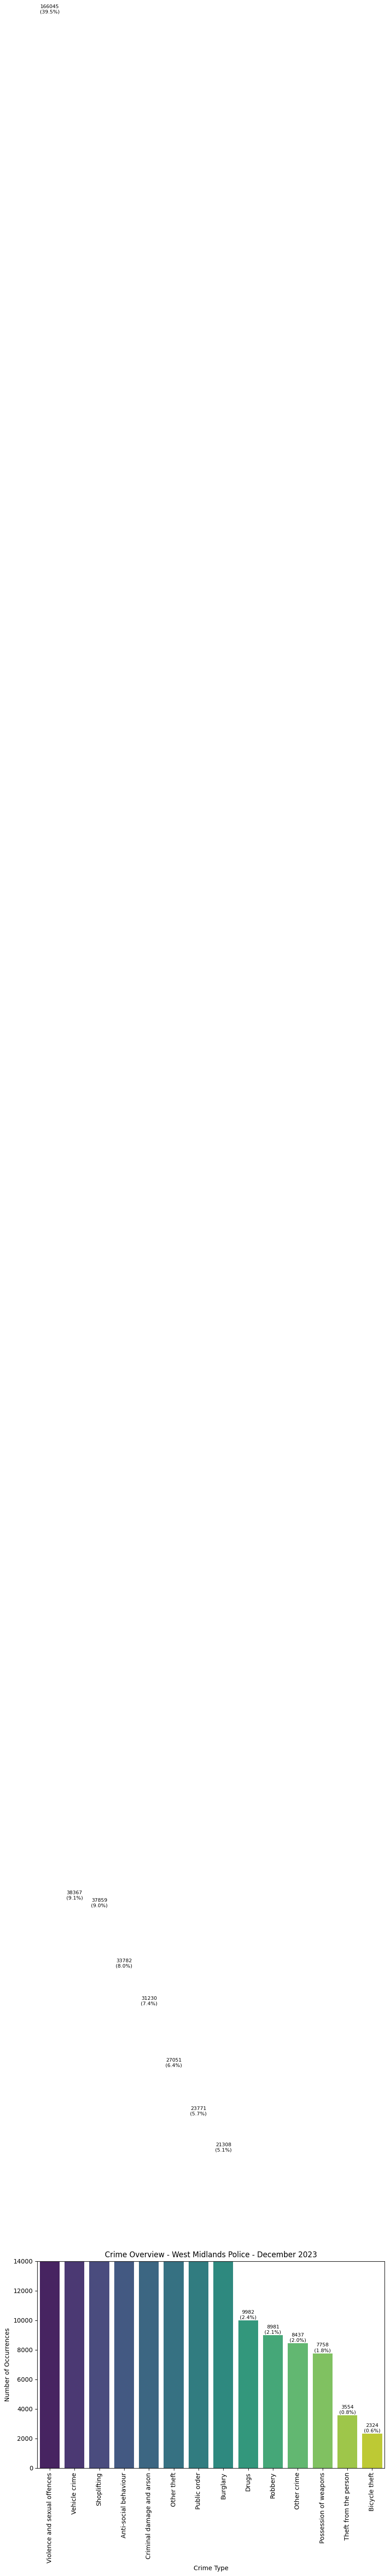

In [ ]:
#Bar Chart with percentages of total % For Crime Types
crime_type_counts = CleanData['Crime type'].value_counts()
total_crimes = crime_type_counts.sum()
crime_type_percentages = (crime_type_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=crime_type_counts.index, y=crime_type_counts.values, hue=crime_type_counts.index, palette='viridis', legend=False)
plt.title('Crime Overview - West Midlands Police - December 2023')
plt.ylim(0, 14000)
plt.xlabel('Crime Type')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(crime_type_counts.values):
    percentage = crime_type_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

/tmp/ipython-input-1557414992.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


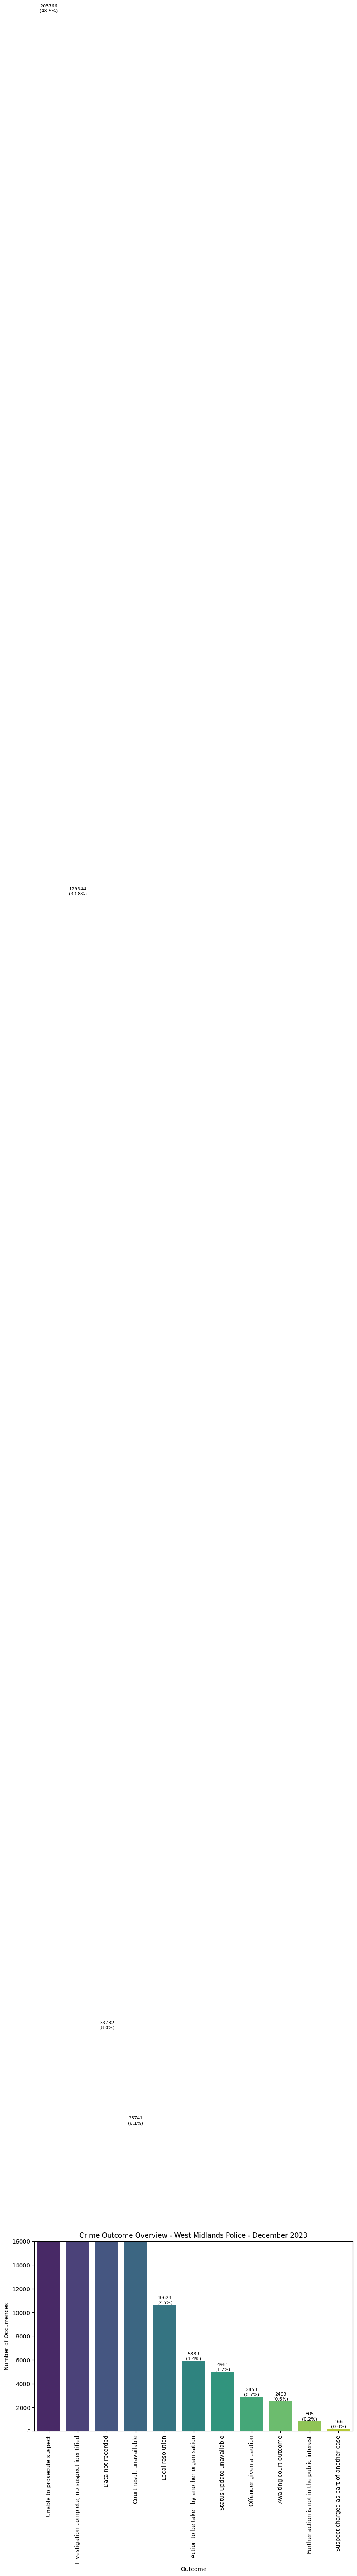

In [ ]:
#Bar Chart with percentages of total %
outcome_counts = CleanData['Last outcome category'].value_counts()
total_crimes = outcome_counts.sum()
outcome_percentages = (outcome_counts / total_crimes * 100).round(1)

plt.figure(figsize=(10, 6))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, hue=outcome_counts.index, palette='viridis', legend=False)
plt.title('Crime Outcome Overview - West Midlands Police - December 2023')
plt.ylim(0, 16000)
plt.xlabel('Outcome')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=90) # Rotate labels for better readability

# Add annotations for count and percentage
for index, value in enumerate(outcome_counts.values):
    percentage = outcome_percentages.iloc[index]
    plt.text(index, value + 50, f'{value}\n({percentage:.1f}%)', color='black', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()